In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("vehicle_data.csv")

# Clean column names
df.columns = df.columns.str.strip().str.lower()

df.head()

,engine_size,horsepower,weight,cylinders,model_year,mpg
0,2.50,173.0,1758.0,3,2010,37.78
1,4.80,252.0,3756.0,4,2002,22.60
2,3.93,216.0,2763.0,8,2000,27.20
3,3.39,261.0,3566.0,4,2005,29.15
4,1.62,110.0,2300.0,3,2017,44.12


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   engine_size  200 non-null    float64
 1   horsepower   200 non-null    float64
 2   weight       200 non-null    float64
 3   cylinders    200 non-null    int64  
 4   model_year   200 non-null    int64  
 5   mpg          200 non-null    float64
dtypes: float64(4), int64(2)
memory usage: 9.5 KB


,engine_size,horsepower,weight,cylinders,model_year,mpg
count,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000
mean,2.935900,190.95000,2801.660000,5.100000,2010.360000,34.743850
std,1.179488,80.07702,768.254397,1.845816,6.936206,6.624813
min,1.020000,54.00000,1527.000000,3.000000,2000.000000,20.000000
25%,1.917500,128.25000,2139.000000,4.000000,2004.000000,29.525000
50%,2.980000,176.50000,2813.500000,4.000000,2009.000000,35.025000
75%,4.025000,259.00000,3527.500000,6.000000,2016.250000,40.072500
max,4.950000,360.00000,3999.000000,8.000000,2023.000000,49.350000


In [4]:
# Remove duplicates
df = df.drop_duplicates()

# Handle missing values
df = df.fillna(df.mean(numeric_only=True))

# Remove outliers (IQR method)
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) |
          (df > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Shape after cleaning:", df.shape)

Shape after cleaning: (200, 6)


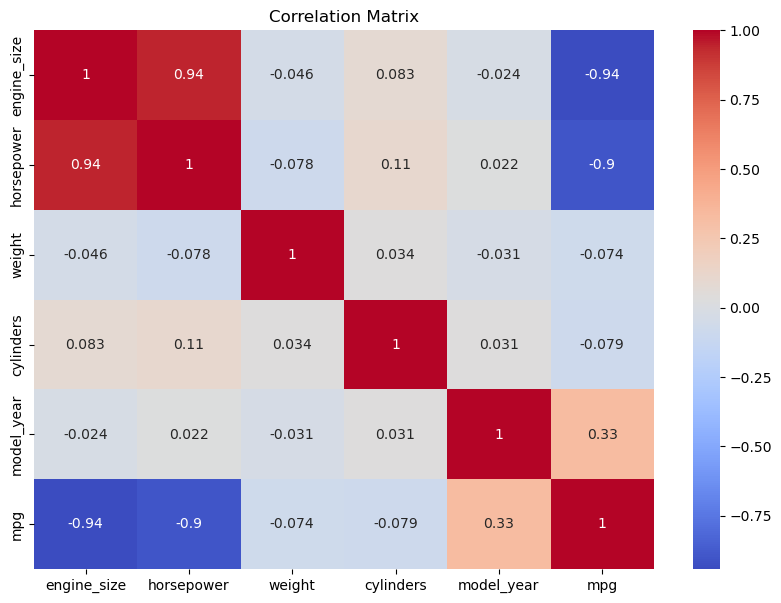

In [5]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

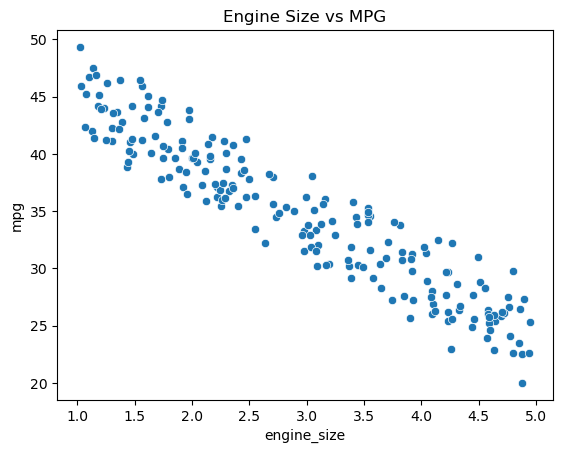

In [ ]:
sns.scatterplot(x="engine_size", y="mpg", data=df)
plt.title("Engine Size vs MPG")
plt.show()

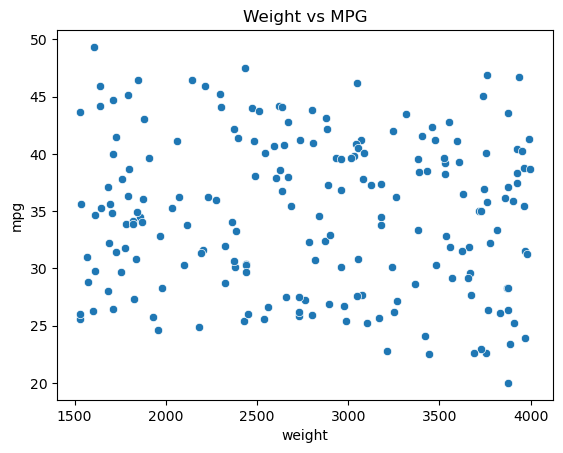

In [7]:
sns.scatterplot(x="weight", y="mpg", data=df)
plt.title("Weight vs MPG")
plt.show()

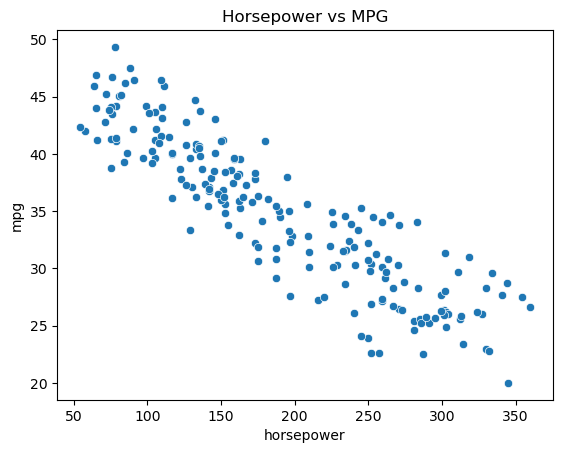

In [8]:
sns.scatterplot(x="horsepower", y="mpg", data=df)
plt.title("Horsepower vs MPG")
plt.show()

In [ ]:
X_simple = df[["engine_size"]]
y = df["mpg"]
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)
simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)
y_pred_s = simple_model.predict(X_test_s)
print("Simple Regression R2:", r2_score(y_test_s, y_pred_s))

Simple Regression R2: 0.8885111728819748


In [10]:
X = df[["engine_size", "horsepower", "weight", "cylinders", "model_year"]]
y = df["mpg"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

cv_scores = cross_val_score(model, X, y, cv=5, scoring="r2")
print("Cross Validation R2:", cv_scores.mean())

MAE: 0.0023552906564193953
MSE: 7.612047814452744e-06
RMSE: 0.0027589939859399377
R2 Score: 0.999999806747475
Cross Validation R2: 0.9999997776282934


In [12]:
joblib.dump(model, "vehicle_fuel_efficiency_model.pkl")
print("Model Saved Successfully!")

Model Saved Successfully!
